# Desafío - Redes neuronales (Parte II)

**Objetivo:** predecir si una reserva hotelera será cancelada (`is_canceled`) usando redes neuronales multicapa con Keras/TensorFlow.

Este notebook sigue la estructura trabajada en los desafíos anteriores:

1. Carga de librerías y datos.
2. Limpieza y revisión de valores ausentes.
3. Análisis descriptivo y tratamiento de outliers.
4. Preparación de variables para modelamiento.
5. Dos redes neuronales multicapa base.
6. Red neuronal con Dropout y búsqueda de grilla con 3 folds.
7. Evaluación final con matriz de confusión, métricas, curva ROC y AUC.
8. Predicción de 5 observaciones del conjunto original.

> Nota práctica: si estás en Google Colab y falta TensorFlow, ejecuta primero la celda de instalación.

## 1. Importación de librerías

In [ ]:
# Si estás en Google Colab/Jupyter y falta alguna librería, descomenta esta celda.
# !pip install tensorflow scikit-learn pandas matplotlib seaborn

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.initializers import GlorotNormal, GlorotUniform

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga de datos

El archivo esperado es `hotel_bookings.csv`. Si no está disponible directamente, el notebook intenta extraerlo desde el zip de apoyo.

In [2]:
csv_file = "hotel_bookings.csv"
zip_candidates = [
    "Apoyo Desafío - Redes neuronales (Parte II).zip",
    "Apoyo Desafío - Redes neuronales (Parte II).zip",
    "Apoyo Desafío - Redes neuronales (Parte II).zip"
]

if not os.path.exists(csv_file):
    zip_found = None
    for z in zip_candidates:
        if os.path.exists(z):
            zip_found = z
            break

    if zip_found is not None:
        with zipfile.ZipFile(zip_found, "r") as zip_ref:
            zip_ref.extractall(".")
    else:
        raise FileNotFoundError(
            "No se encontró hotel_bookings.csv ni el zip de apoyo. "
            "Sube el archivo CSV o el zip al mismo directorio del notebook."
        )

df_original = pd.read_csv(csv_file)
df = df_original.copy()

print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (119390, 33)


,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies          

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,119390.0,NaN,NaN,NaN,59694.5,34465.068657,0.0,29847.25,59694.5,89541.75,119389.0
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0


## 3. Limpieza inicial

Según el enunciado, se deben descartar las columnas: `index`, `arrival_date_year`, `agent`, `country`, `company`, `reservation_status` y `reservation_status_date`.

In [5]:
# Normalizar nombres de columnas por seguridad.
df.columns = df.columns.str.strip()

columnas_eliminar = [
    "index", "arrival_date_year", "agent", "country", "company",
    "reservation_status", "reservation_status_date"
]

df = df.drop(columns=[c for c in columnas_eliminar if c in df.columns])

print("Dimensiones después de eliminar columnas:", df.shape)
df.head()

Dimensiones después de eliminar columnas: (119390, 26)


,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,27,1,0,0,2,0.0,...,0,C,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,July,27,1,0,0,2,0.0,...,0,C,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,July,27,1,0,1,1,0.0,...,0,A,C,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,July,27,1,0,1,1,0.0,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,July,27,1,0,2,2,0.0,...,0,A,A,0,No Deposit,0,Transient,98.0,0,1


### 3.1 Revisión de valores ausentes

La regla del desafío es:

- Si los valores ausentes representan menos del 4% del total, se eliminan esos registros.
- Si superan el 4%, se decide entre eliminar la característica o imputar.

En esta base, después de eliminar las columnas solicitadas, normalmente queda `children` con muy pocos nulos, por lo que se eliminan esas filas.

In [6]:
nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (nulos / len(df) * 100).round(4)

resumen_nulos = pd.DataFrame({
    "nulos": nulos,
    "% nulos": porcentaje_nulos
})
resumen_nulos[resumen_nulos["nulos"] > 0]

,nulos,% nulos
children,4,0.0034


In [8]:
total_filas = len(df)
filas_con_nulos = df.isnull().any(axis=1).sum() #recorremos la fila buscando nulos
porc_filas_con_nulos = filas_con_nulos / total_filas * 100

print(f"Filas con al menos un nulo: {filas_con_nulos}")
print(f"Porcentaje de filas con nulos: {porc_filas_con_nulos:.4f}%")

if porc_filas_con_nulos < 4:
    df = df.dropna().copy()
    print("Se eliminaron las filas con nulos porque representan menos del 4%.")
else:
    # Estrategia defensiva por si la base cambia en el futuro.
    # Numéricas: mediana. Categóricas: moda.
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == "object":
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())
    print("Se imputaron valores nulos porque superaban el 4%.")

print("Dimensiones después de tratar nulos:", df.shape)

Filas con al menos un nulo: 0
Porcentaje de filas con nulos: 0.0000%
Se eliminaron las filas con nulos porque representan menos del 4%.
Dimensiones después de tratar nulos: (119386, 26)


## 4. Análisis descriptivo y preparación de datos

### 4.1 Selección de 5 variables relevantes

Se seleccionan estas variables por su relación lógica con la cancelación:

- `lead_time`: mientras más anticipación, más probabilidad de que cambien los planes.
- `deposit_type`: las reservas con depósito no reembolsable suelen comportarse distinto.
- `previous_cancellations`: historial de cancelaciones previas.
- `total_of_special_requests`: solicitudes especiales pueden indicar mayor compromiso con la reserva.
- `required_car_parking_spaces`: pedir estacionamiento puede indicar mayor intención de asistir.

No se usa `adr` en esta selección porque el enunciado pide excluirla de estas 5 variables.

In [9]:
variables_relevantes = [
    "lead_time",
    "deposit_type",
    "previous_cancellations",
    "total_of_special_requests",
    "required_car_parking_spaces"
]

for col in variables_relevantes:
    print(f"\nVariable: {col}")
    if df[col].dtype == "object":
        display(pd.crosstab(df[col], df["is_canceled"], normalize="index").round(3))
    else:
        display(df.groupby("is_canceled")[col].describe().round(2))


Variable: lead_time


,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.98,91.11,0.0,9.0,45.0,124.0,737.0
1,44220.0,144.86,118.62,0.0,48.0,113.0,214.0,629.0



Variable: deposit_type


is_canceled,0,1
deposit_type,,
No Deposit,0.716,0.284
Non Refund,0.006,0.994
Refundable,0.778,0.222



Variable: previous_cancellations


,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,0.02,0.27,0.0,0.0,0.0,0.0,13.0
1,44220.0,0.21,1.33,0.0,0.0,0.0,0.0,26.0



Variable: total_of_special_requests


,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,0.71,0.83,0.0,0.0,1.0,1.0,5.0
1,44220.0,0.33,0.65,0.0,0.0,0.0,0.0,5.0



Variable: required_car_parking_spaces


,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,0.1,0.3,0.0,0.0,0.0,0.0,8.0
1,44220.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4.2 Histograma de `adr` según cancelación

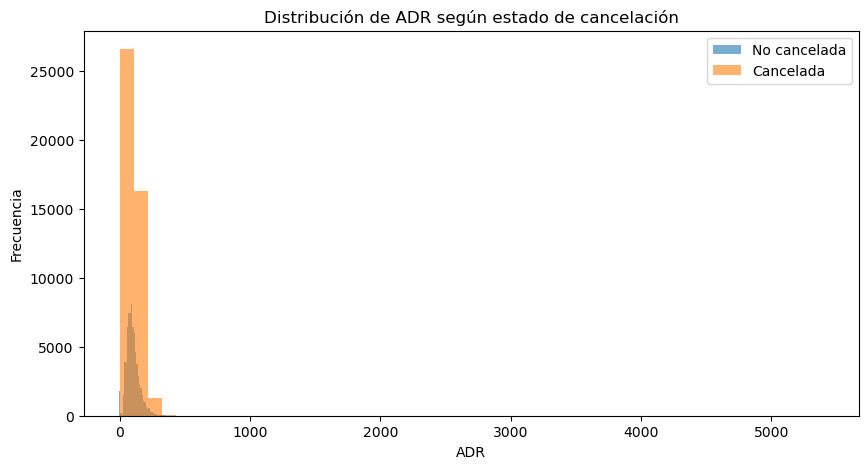

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df.loc[df["is_canceled"] == 0, "adr"], bins=50, alpha=0.6, label="No cancelada")
plt.hist(df.loc[df["is_canceled"] == 1, "adr"], bins=50, alpha=0.6, label="Cancelada")
plt.title("Distribución de ADR según estado de cancelación")
plt.xlabel("ADR")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

**Comentario:** la variable `adr` se concentra en valores bajos y medios para ambos grupos. Las reservas canceladas y no canceladas se superponen bastante, por lo que `adr` puede aportar información, pero no parece suficiente por sí sola para separar perfectamente las clases. También se observan valores extremos, por eso se revisan outliers.

### 4.3 Revisión y tratamiento de outliers en `adr`

Se usa el criterio IQR:

- Límite inferior = Q1 - 1.5 × IQR.
- Límite superior = Q3 + 1.5 × IQR.

El desafío pide eliminar solo los 3 valores más extremos por arriba y por abajo. Para los demás outliers, se reemplaza su valor por el promedio de `adr`.

In [11]:
q1 = df["adr"].quantile(0.25)
q3 = df["adr"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_abajo = df[df["adr"] < limite_inferior].copy()
outliers_arriba = df[df["adr"] > limite_superior].copy()

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Outliers por abajo: {len(outliers_abajo)}")
print(f"Outliers por arriba: {len(outliers_arriba)}")

Q1: 69.29
Q3: 126.00
IQR: 56.71
Límite inferior: -15.77
Límite superior: 211.06
Outliers por abajo: 0
Outliers por arriba: 3793


In [12]:
# Guardamos una copia antes de excluir los valores extremos.
df_sin_exclusion = df.copy()

idx_extremos_abajo = df.nsmallest(3, "adr").index
idx_extremos_arriba = df.nlargest(3, "adr").index
idx_eliminar = idx_extremos_abajo.union(idx_extremos_arriba)

df_modelo = df.drop(index=idx_eliminar).copy()

promedio_adr = df_modelo["adr"].mean()

mask_outliers_restantes = (
    (df_modelo["adr"] < limite_inferior) |
    (df_modelo["adr"] > limite_superior)
)

print("Filas eliminadas por extremos:", len(idx_eliminar))
print("Outliers restantes reemplazados por promedio:", mask_outliers_restantes.sum())
print("Promedio ADR usado para reemplazo:", round(promedio_adr, 2))

df_modelo.loc[mask_outliers_restantes, "adr"] = promedio_adr

print("Dimensiones finales para modelamiento:", df_modelo.shape)

Filas eliminadas por extremos: 6
Outliers restantes reemplazados por promedio: 3790
Promedio ADR usado para reemplazo: 101.78
Dimensiones finales para modelamiento: (119380, 26)


### 4.4 Variables dummies, estandarización y división train/test

El conjunto de test debe tener 33% de los registros.

In [13]:
X = df_modelo.drop(columns="is_canceled")
y = df_modelo["is_canceled"].astype(int)

X_dummies = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y,
    test_size=0.33,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("Distribución y_train:")
print(y_train.value_counts(normalize=True).round(3))
print("Distribución y_test:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (79984, 67)
X_test: (39396, 67)
Distribución y_train:
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64
Distribución y_test:
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


## 5. Modelos de red neuronal multicapa

Requisitos:

- Dos modelos.
- Cada modelo con tres capas ocultas.
- Mínimo 20 neuronas por capa oculta.
- Modelo 1: activaciones `tanh`, `relu`, `tanh`.
- Modelo 2: activaciones `tanh`, `tanh`, `tanh`.
- Optimizador `SGD`.
- 10 épocas.
- Cada capa densa incluye sesgo (`use_bias=True`).
- Inicialización elegida: `glorot_uniform` para pesos y `zeros` para sesgos. Esta combinación es estándar y estable para redes densas.

In [14]:
def crear_modelo_base(input_dim, activaciones, neuronas=32):
    modelo = Sequential()
    modelo.add(Dense(
        neuronas,
        activation=activaciones[0],
        input_dim=input_dim,
        kernel_initializer="glorot_uniform",
        bias_initializer="zeros",
        use_bias=True
    ))
    modelo.add(Dense(
        neuronas,
        activation=activaciones[1],
        kernel_initializer="glorot_uniform",
        bias_initializer="zeros",
        use_bias=True
    ))
    modelo.add(Dense(
        neuronas,
        activation=activaciones[2],
        kernel_initializer="glorot_uniform",
        bias_initializer="zeros",
        use_bias=True
    ))
    modelo.add(Dense(
        1,
        activation="sigmoid",
        kernel_initializer="glorot_uniform",
        bias_initializer="zeros",
        use_bias=True
    ))

    modelo.compile(
        optimizer=SGD(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

In [15]:
input_dim = X_train_scaled.shape[1]

modelo_1 = crear_modelo_base(input_dim, activaciones=["tanh", "relu", "tanh"], neuronas=32)
modelo_2 = crear_modelo_base(input_dim, activaciones=["tanh", "tanh", "tanh"], neuronas=32)

historial_1 = modelo_1.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=10,
    batch_size=256,
    verbose=1
)

historial_2 = modelo_2.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6541 - loss: 0.6220 - val_accuracy: 0.7310 - val_loss: 0.5714
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7555 - loss: 0.5370 - val_accuracy: 0.7693 - val_loss: 0.5043
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7786 - loss: 0.4865 - val_accuracy: 0.7840 - val_loss: 0.4708
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7870 - loss: 0.4620 - val_accuracy: 0.7914 - val_loss: 0.4547
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7928 - loss: 0.4490 - val_accuracy: 0.7951 - val_loss: 0.4452
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7972 - loss: 0.4403 - val_accuracy: 0.7985 - val_loss: 0.4382
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8005 - loss: 0.4337 - val_accuracy: 0.8003 - val_loss: 0.4326
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8032 - loss: 0.4284 - val_accuracy: 0.

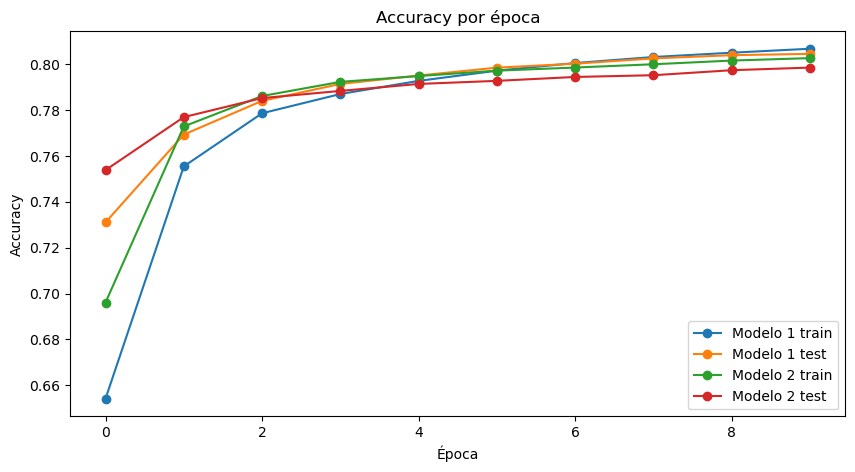

Accuracy final Modelo 1 test: 0.8045
Accuracy final Modelo 2 test: 0.7986


In [16]:
plt.figure(figsize=(10, 5))
plt.plot(historial_1.history["accuracy"], marker="o", label="Modelo 1 train")
plt.plot(historial_1.history["val_accuracy"], marker="o", label="Modelo 1 test")
plt.plot(historial_2.history["accuracy"], marker="o", label="Modelo 2 train")
plt.plot(historial_2.history["val_accuracy"], marker="o", label="Modelo 2 test")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

acc_m1 = historial_1.history["val_accuracy"][-1]
acc_m2 = historial_2.history["val_accuracy"][-1]

print(f"Accuracy final Modelo 1 test: {acc_m1:.4f}")
print(f"Accuracy final Modelo 2 test: {acc_m2:.4f}")

**Conclusión esperada:** ambos modelos deberían superar el 75% de accuracy. Si el modelo con `relu` en la segunda capa aprende más rápido, es normal: `relu` suele facilitar el aprendizaje en capas ocultas. Si el modelo con solo `tanh` queda muy cerca, también es razonable porque la base está estandarizada.

## 6. Red neuronal con Dropout y búsqueda de grilla con 3 folds

La grilla solicitada considera:

- Capas ocultas: 3 o 4.
- Optimizador: Adam o SGD.
- Learning rate: 0.03 o 0.06.
- Neuronas por capa oculta: 20.
- Activación: tanh.
- Dropout: 0.001.
- Inicialización de pesos: `glorot_normal` o `glorot_uniform`.

Se implementa manualmente con `StratifiedKFold` para evitar depender de wrappers externos como SciKeras.

In [17]:
def crear_modelo_dropout(
    input_dim,
    hidden_layers=3,
    optimizer_name="adam",
    learning_rate=0.03,
    neurons=20,
    activation="tanh",
    dropout_rate=0.001,
    kernel_initializer="glorot_uniform"
):
    modelo = Sequential()

    for i in range(hidden_layers):
        if i == 0:
            modelo.add(Dense(
                neurons,
                activation=activation,
                input_dim=input_dim,
                kernel_initializer=kernel_initializer,
                bias_initializer="zeros",
                use_bias=True
            ))
        else:
            modelo.add(Dense(
                neurons,
                activation=activation,
                kernel_initializer=kernel_initializer,
                bias_initializer="zeros",
                use_bias=True
            ))
        modelo.add(Dropout(dropout_rate))

    modelo.add(Dense(
        1,
        activation="sigmoid",
        kernel_initializer=kernel_initializer,
        bias_initializer="zeros",
        use_bias=True
    ))

    if optimizer_name.lower() == "adam":
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = SGD(learning_rate=learning_rate)

    modelo.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [18]:
param_grid = {
    "hidden_layers": [3, 4],
    "optimizer_name": ["adam", "sgd"],
    "learning_rate": [0.03, 0.06],
    "neurons": [20],
    "activation": ["tanh"],
    "dropout_rate": [0.001],
    "kernel_initializer": ["glorot_normal", "glorot_uniform"]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
resultados_grid = []

# Para trabajar con arreglos numpy dentro de los folds.
X_train_np = np.asarray(X_train_scaled).astype("float32")
y_train_np = np.asarray(y_train).astype("int32")

for params in ParameterGrid(param_grid):
    acc_folds = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np), start=1):
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        modelo = crear_modelo_dropout(input_dim=input_dim, **params)

        modelo.fit(
            X_train_np[train_idx], y_train_np[train_idx],
            validation_data=(X_train_np[val_idx], y_train_np[val_idx]),
            epochs=10,
            batch_size=256,
            verbose=0
        )

        pred_val_prob = modelo.predict(X_train_np[val_idx], verbose=0).ravel()
        pred_val = (pred_val_prob >= 0.5).astype(int)
        acc = accuracy_score(y_train_np[val_idx], pred_val)
        acc_folds.append(acc)

    resultado = params.copy()
    resultado["accuracy_promedio_cv"] = np.mean(acc_folds)
    resultado["accuracy_std_cv"] = np.std(acc_folds)
    resultados_grid.append(resultado)

resultados_grid_df = pd.DataFrame(resultados_grid).sort_values(
    by="accuracy_promedio_cv", ascending=False
)

resultados_grid_df

,activation,dropout_rate,hidden_layers,kernel_initializer,learning_rate,neurons,optimizer_name,accuracy_promedio_cv,accuracy_std_cv
0,tanh,0.001,3,glorot_normal,0.03,20,adam,0.816238,0.002468
4,tanh,0.001,3,glorot_uniform,0.03,20,adam,0.816226,0.003034
7,tanh,0.001,3,glorot_uniform,0.06,20,sgd,0.816113,0.001488
11,tanh,0.001,4,glorot_normal,0.06,20,sgd,0.813613,0.000413
3,tanh,0.001,3,glorot_normal,0.06,20,sgd,0.813588,0.001837
15,tanh,0.001,4,glorot_uniform,0.06,20,sgd,0.813388,0.001977
8,tanh,0.001,4,glorot_normal,0.03,20,adam,0.811537,0.001240
12,tanh,0.001,4,glorot_uniform,0.03,20,adam,0.810362,0.003489
5,tanh,0.001,3,glorot_uniform,0.03,20,sgd,0.809699,0.001186
9,tanh,0.001,4,glorot_normal,0.03,20,sgd,0.809299,0.001196


In [19]:
mejores_parametros = resultados_grid_df.iloc[0].drop(["accuracy_promedio_cv", "accuracy_std_cv"]).to_dict()

print("Mejores hiperparámetros encontrados:")
for k, v in mejores_parametros.items():
    print(f"{k}: {v}")

print("\nAccuracy promedio CV:", round(resultados_grid_df.iloc[0]["accuracy_promedio_cv"], 4))

Mejores hiperparámetros encontrados:
activation: tanh
dropout_rate: 0.001
hidden_layers: 3
kernel_initializer: glorot_normal
learning_rate: 0.03
neurons: 20
optimizer_name: adam

Accuracy promedio CV: 0.8162


## 7. Entrenamiento del mejor modelo y evaluación en test

In [20]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

mejor_modelo = crear_modelo_dropout(input_dim=input_dim, **mejores_parametros)

historial_mejor = mejor_modelo.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8016 - loss: 0.4211 - val_accuracy: 0.8067 - val_loss: 0.4058
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8149 - loss: 0.3991 - val_accuracy: 0.8149 - val_loss: 0.3958
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8183 - loss: 0.3928 - val_accuracy: 0.8163 - val_loss: 0.3928
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8185 - loss: 0.3899 - val_accuracy: 0.8167 - val_loss: 0.3928
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8195 - loss: 0.3877 - val_accuracy: 0.8142 - val_loss: 0.3950
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8184 - loss: 0.3887 - val_accuracy: 0.8164 - val_loss: 0.3917
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8184 - loss: 0.3879 - val_accuracy: 0.8175 - val_loss: 0.3924
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8205 - loss: 0.3868 - val_accuracy: 0.

In [21]:
y_prob = mejor_modelo.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Valor": [acc, precision, recall, f1, auc]
})

display(metricas.round(4))
print("Matriz de confusión:")
print(cm)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

,Métrica,Valor
0,Accuracy,0.8177
1,Precision,0.8530
2,Recall,0.6136
3,F1-score,0.7137
4,AUC,0.8840


Matriz de confusión:
[[23261  1543]
 [ 5639  8953]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.94      0.87     24804
           1       0.85      0.61      0.71     14592

    accuracy                           0.82     39396
   macro avg       0.83      0.78      0.79     39396
weighted avg       0.82      0.82      0.81     39396



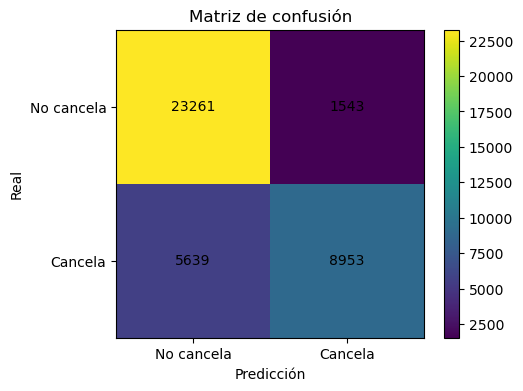

In [22]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], ["No cancela", "Cancela"])
plt.yticks([0, 1], ["No cancela", "Cancela"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

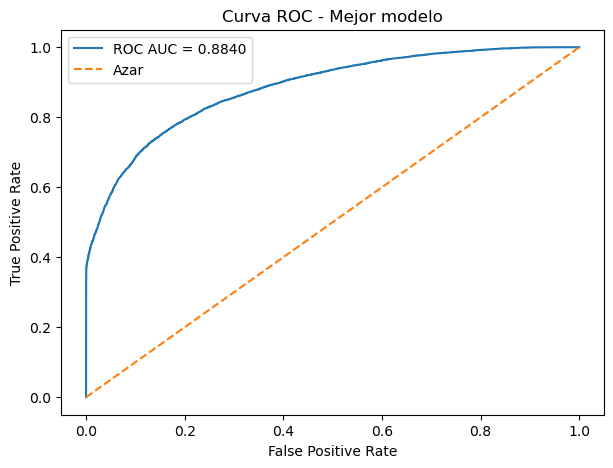

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.title("Curva ROC - Mejor modelo")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**Conclusión esperada:** el modelo con Dropout y búsqueda de grilla debería superar el 80% de accuracy. La gracia está en encontrar una combinación estable de arquitectura, optimizador, learning rate e inicialización.

## 8. Predicción de 5 observaciones del conjunto original

El enunciado pide usar el conjunto original **sin los valores excluidos** y escoger al azar cinco observaciones donde `deposit_type_Non Refund` sea cero.

Como `deposit_type_Non Refund` aparece después de crear dummies, se prepara el conjunto original con el mismo esquema de columnas usado para entrenar.

In [24]:
# Partimos desde df_sin_exclusion, es decir, antes de eliminar los 6 extremos de ADR.
X_original = df_sin_exclusion.drop(columns="is_canceled")
y_original = df_sin_exclusion["is_canceled"].astype(int)

X_original_dummies = pd.get_dummies(X_original, drop_first=True)

# Alinear columnas con las usadas en entrenamiento.
X_original_dummies = X_original_dummies.reindex(columns=X_train.columns, fill_value=0)

if "deposit_type_Non Refund" not in X_original_dummies.columns:
    raise ValueError("No existe la columna deposit_type_Non Refund después de crear dummies.")

observaciones_5 = X_original_dummies[X_original_dummies["deposit_type_Non Refund"] == 0].sample(
    n=5, random_state=SEED
)

observaciones_5_scaled = scaler.transform(observaciones_5)
prob_5 = mejor_modelo.predict(observaciones_5_scaled, verbose=0).ravel()
pred_5 = (prob_5 >= 0.5).astype(int)

resultado_5 = pd.DataFrame({
    "indice_original": observaciones_5.index,
    "probabilidad_cancelacion": prob_5,
    "prediccion": pred_5,
    "interpretacion": np.where(pred_5 == 1, "Cancelaría", "No cancelaría"),
    "valor_real": y_original.loc[observaciones_5.index].values
})

resultado_5.round(4)

,indice_original,probabilidad_cancelacion,prediccion,interpretacion,valor_real
0,15503,0.0081,0,No cancelaría,0
1,111019,0.1115,0,No cancelaría,0
2,112319,0.2833,0,No cancelaría,0
3,52343,0.5651,1,Cancelaría,1
4,46146,0.1228,0,No cancelaría,0


**Comentario:** estas cinco predicciones muestran cómo el modelo aplica lo aprendido en casos donde `deposit_type_Non Refund` es cero. La columna `probabilidad_cancelacion` permite interpretar el riesgo: mientras más cerca de 1, mayor probabilidad estimada de cancelación; mientras más cerca de 0, menor probabilidad estimada.

## 9. Cierre

En este desafío se construyeron modelos de red neuronal para clasificación binaria. Primero se preparó la base, se trataron nulos y outliers, luego se compararon dos arquitecturas multicapa y finalmente se ajustó una red con Dropout mediante búsqueda de grilla con validación cruzada de 3 folds.

El mejor modelo se evaluó con accuracy, precision, recall, F1, matriz de confusión, curva ROC y AUC.